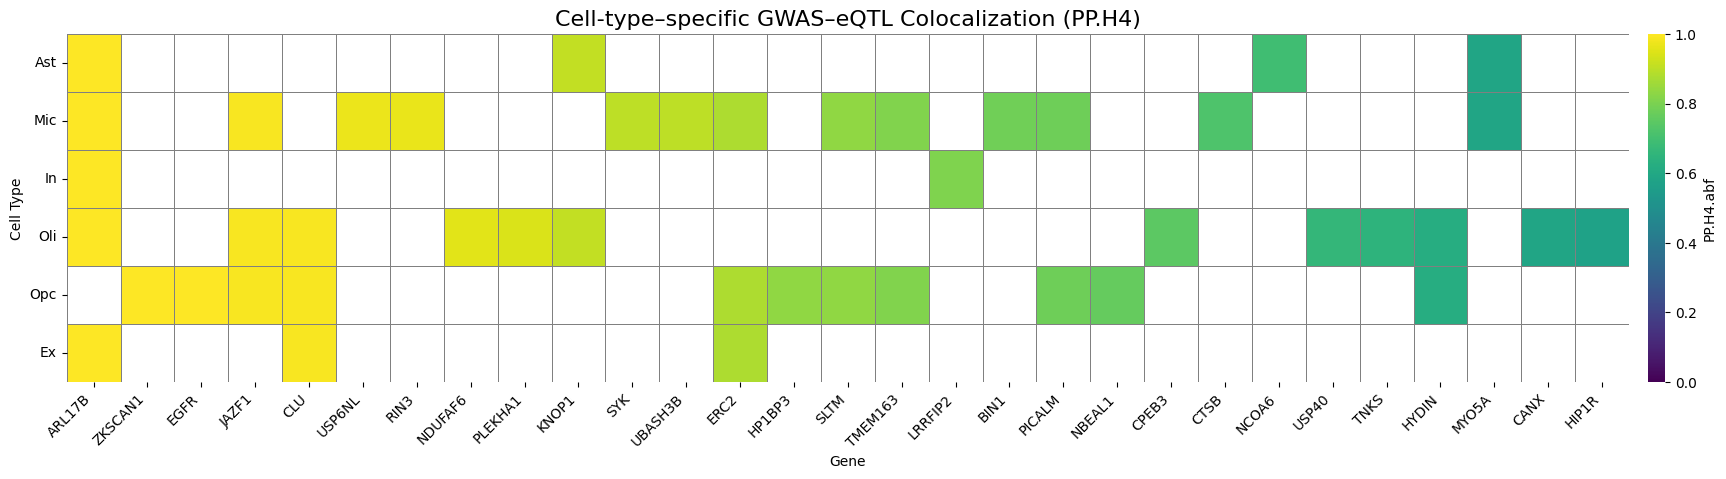

Saved PP.H4 heatmap to: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure_Coloc/heatmap_PP_H4_celltype_by_gene.png


In [4]:
# ============================================================
# Cell-type × Gene Colocalization Heatmap (PP.H4)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Paths ===
coloc_path = "/n/scratch/users/a/adm808/Revision/Coloc/coloc_results_AD_GWAS_GTEx_v10_Cortex_and_BA9_all_brain.csv"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure_Coloc/"
os.makedirs(out_dir, exist_ok=True)

# === Cell types (order fixed) ===
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]

# === Parameters ===
PPH4_THRESHOLD = 0.5
TOP_N_GENES = 80   # adjust if needed

# === Load data ===
df = pd.read_csv(coloc_path)

# Safety: ensure correct column names
required_cols = ["gene_symbol", "cell_type", "PP.H4.abf"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# === Keep only relevant cell types ===
df = df[df["cell_type"].isin(cell_types)]

# === Aggregate across tissues: take max PP.H4 per gene × cell type ===
agg = (
    df
    .groupby(["gene_symbol", "cell_type"])["PP.H4.abf"]
    .max()
    .reset_index()
)

# === Pivot to cell_type × gene ===
heatmap_df = agg.pivot(
    index="cell_type",
    columns="gene_symbol",
    values="PP.H4.abf"
)

# Reindex to enforce row order
heatmap_df = heatmap_df.reindex(cell_types)

# === Gene filtering: keep genes with strong colocalization somewhere ===
genes_with_signal = heatmap_df.columns[
    heatmap_df.max(axis=0) >= PPH4_THRESHOLD
]

heatmap_df = heatmap_df[genes_with_signal]

# === Limit to top N genes by mean PP.H4 ===
gene_means = heatmap_df.mean(axis=0)
top_genes = gene_means.sort_values(ascending=False).head(TOP_N_GENES).index
heatmap_df = heatmap_df[top_genes]

# === Final sorting for clean gradient ===
heatmap_df = heatmap_df[
    heatmap_df.mean(axis=0).sort_values(ascending=False).index
]

# === Plot ===
plt.figure(figsize=(24, 6))
sns.heatmap(
    heatmap_df,
    cmap="viridis",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "PP.H4.abf", "pad": 0.01},
    vmin=0,
    vmax=1
)

plt.title("Cell-type–specific GWAS–eQTL Colocalization (PP.H4)", fontsize=16)
plt.xlabel("Gene")
plt.ylabel("Cell Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.subplots_adjust(bottom=0.3)

out_path = os.path.join(out_dir, "heatmap_PP_H4_celltype_by_gene.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PP.H4 heatmap to: {out_path}")

In [1]:
print("Hello")

Hello


In [ ]:
# Two-way Venns per cell type: Pathology AD GWAS vs Clinical AD GWAS
# Labels show counts + top <=5 genes ranked by smallest GWAS p-value.

import os
import joblib
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# ================= CONFIG =================
cerad_base_dir    = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
clinical_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
gwas_path         = "/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv"

output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure10"
os.makedirs(output_dir, exist_ok=True)

ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

min_splits_required = 2
split_indices = range(1, 6)
exclude_prefixes = ("age_death", "msex", "apoe_geno", "educ")

# Optional: treat RASGEF1B as present in GWAS if RASGEF1C is in GWAS
apply_rasgef1b_equivalence = True

plt.rcParams.update({"font.size": 10})

# ================= HELPERS =================
def load_predictors(base_dir):
    preds = {}
    for ct in cell_types:
        gene_presence = defaultdict(int)
        for split in split_indices:
            p = os.path.join(base_dir, ct, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(p):
                continue
            model = joblib.load(p)
            feature_names = getattr(model, "feature_names_in_", None)
            importances   = getattr(model, "feature_importances_", None)
            if feature_names is None or importances is None:
                print(f"[WARN] Missing attrs in {p}; skipping this split.")
                continue
            for gene, imp in zip(feature_names, importances):
                if imp <= 0:
                    continue
                gl = str(gene).lower()
                if any(gl.startswith(pref) for pref in exclude_prefixes):
                    continue
                gene_presence[str(gene).upper()] += 1
        preds[ct] = {g for g, c in gene_presence.items() if c >= min_splits_required}
        print(f"{ct}: {len(preds[ct])} predictors from {base_dir}")
    return preds

def load_gwas_gene_pvals(gwas_tsv):
    """Return: set_of_genes, dict gene->best_pval (min p across rows; None if NR)."""
    df = pd.read_csv(gwas_tsv, sep="\t", low_memory=False)
    gene_to_p = {}
    for _, row in df.dropna(subset=["mappedGenes"]).iterrows():
        raw_p = row.get("pValue", None)
        try:
            pval = float(raw_p) if raw_p != "NR" else None
        except Exception:
            pval = None
        for g in str(row["mappedGenes"]).split(","):
            g = g.strip().upper()
            if not g:
                continue
            # keep the most significant (smallest) p-value per gene
            if g not in gene_to_p or (
                pval is not None and (gene_to_p[g] is None or pval < gene_to_p[g])
            ):
                gene_to_p[g] = pval
    genes = set(gene_to_p.keys())
    return genes, gene_to_p

def rank_genes_by_p(genes, pmap):
    # sort by p asc; None goes to end
    return sorted(genes, key=lambda g: (1 if pmap.get(g) is None else 0, pmap.get(g, 1e9), g))

# def label_region(label_obj, genes, pmap, top_k=5):
#     if label_obj is None:
#         return
#     if not genes:
#         label_obj.set_text("0")
#         return
#     top = rank_genes_by_p(list(genes), pmap)[:top_k]
#     label_obj.set_text(f"{len(genes)}\n" + "\n".join(top))

# # ================= MAIN =================
# def main():
#     cerad_preds    = load_predictors(cerad_base_dir)
#     clinical_preds = load_predictors(clinical_base_dir)
#     gwas_genes, gwas_p = load_gwas_gene_pvals(gwas_path)

#     for ct in cell_types:
#         # Subset BOTH predictor sets to GWAS genes first (so only two sets remain)
#         A = cerad_preds.get(ct, set())    & gwas_genes  # Pathology AD GWAS
#         B = clinical_preds.get(ct, set()) & gwas_genes  # Clinical AD GWAS

#         # Make 2-set venn
#         plt.figure(figsize=(7, 7))
#         v = venn2([A, B],
#                   set_labels=("Pathology AD GWAS", "Clinical AD GWAS"),
#                   set_colors=("#7aa6d6", "#f2a6a6"),
#                   alpha=0.8)

#         # Left-only, right-only, overlap
#         A_only = A - B
#         B_only = B - A
#         AB     = A & B

#         label_region(v.get_label_by_id('10'), A_only, gwas_p, top_k=5)
#         label_region(v.get_label_by_id('01'), B_only, gwas_p, top_k=5)
#         label_region(v.get_label_by_id('11'), AB,     gwas_p, top_k=5)

#         plt.title(ct_labels[ct], fontsize=14)
#         plt.tight_layout()
#         out_path = os.path.join(output_dir, f"gwas_overlap_venn_{ct}.png")
#         plt.savefig(out_path, dpi=300)
#         plt.show()
#         print(f"Saved: {out_path}")

def label_region(label_obj, genes, pmap, top_k=5):
    if label_obj is None:
        return
    if not genes:
        label_obj.set_text("0")
        return
    top = rank_genes_by_p(list(genes), pmap)[:top_k]
    # Show top genes first, then bold total count (no parentheses)
    label_obj.set_text("\n".join(top) + f"\n" + r"$\mathbf{" + str(len(genes)) + "}$")

# ================= MAIN =================
def main():
    cerad_preds    = load_predictors(cerad_base_dir)
    clinical_preds = load_predictors(clinical_base_dir)
    gwas_genes, gwas_p = load_gwas_gene_pvals(gwas_path)

    for ct in cell_types:
        A = cerad_preds.get(ct, set())    & gwas_genes
        B = clinical_preds.get(ct, set()) & gwas_genes

        plt.figure(figsize=(7, 7))
        v = venn2([A, B],
                  set_labels=("Pathology AD GWAS", "Clinical AD GWAS"),
                  set_colors=("#7aa6d6", "#f2a6a6"),
                  alpha=0.8)

        A_only = A - B
        B_only = B - A
        AB     = A & B

        label_region(v.get_label_by_id('10'), A_only, gwas_p, top_k=5)
        label_region(v.get_label_by_id('01'), B_only, gwas_p, top_k=5)
        label_region(v.get_label_by_id('11'), AB,     gwas_p, top_k=5)

        # Fixed title position
        plt.title(ct_labels[ct], fontsize=14, y=1.05)

        plt.tight_layout()
        out_path = os.path.join(output_dir, f"gwas_overlap_venn_{ct}.png")
        plt.savefig(out_path, dpi=300)
        plt.show()
        print(f"Saved: {out_path}")

if __name__ == "__main__":
    main()

/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

Ast: 104 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh